# Bit Coin Analysis

## Exploratory Data Analysis

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
bitcoin = pd.read_csv("bitcoin.csv")
bitcoin.head()

,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


In [3]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5883 entries, 0 to 5882
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5883 non-null   object 
 1   Open           5883 non-null   float64
 2   High           5883 non-null   float64
 3   Low            5883 non-null   float64
 4   Close          5883 non-null   float64
 5   Volume         5883 non-null   float64
 6   PriceCategory  5883 non-null   object 
dtypes: float64(5), object(2)
memory usage: 321.9+ KB


In [6]:
bitcoin.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
PriceCategory    0
dtype: int64

In [9]:
bitcoin['Date'] = pd.to_datetime(bitcoin['Date'])
bitcoin['Year'] = bitcoin['Date'].dt.year
bitcoin['Month'] = bitcoin['Date'].dt.month
bitcoin['Day'] = bitcoin['Date'].dt.day
bitcoin['DayOfWeek'] = bitcoin['Date'].dt.day_name()  # Monday, Tuesday, etc.
bitcoin['Week'] = bitcoin['Date'].dt.isocalendar().week
bitcoin['Quarter'] = bitcoin['Date'].dt.quarter
bitcoin.head()

,Date,Open,High,Low,Close,Volume,PriceCategory,Year,Month,Day,DayOfWeek,Week,Quarter
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low,2010,1,1,Friday,53,1
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low,2010,1,2,Saturday,53,1
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low,2010,1,3,Sunday,53,1
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low,2010,1,4,Monday,1,1
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low,2010,1,5,Tuesday,1,1


### Daily Performance

In [22]:
def complete_bitcoin_analysis(df):
    """
    Complete Bitcoin analysis combining:
    - Returns
    - Volatility (price range)
    - Temporal features
    - Price position
    """
    df_copy = df.copy()
    
    # ===========================================
    # 3. VOLATILITY FEATURES
    # ===========================================
    # Price Range (absolute difference)
    df_copy['PriceRange'] = df_copy['High'] - df_copy['Low']
    
    # Daily volatility as percentage of close
    df_copy['Volatility'] = ((df_copy['High'] - df_copy['Low']) / df_copy['Close']) * 100
    
    # Range relative to open (another perspective)
    df_copy['PriceRange_Pct'] = ((df_copy['High'] - df_copy['Low']) / df_copy['Open']) * 100
    
    # ===========================================
    # 4. PRICE POSITION (where did it close relative to the range)
    # ===========================================
    # Close position in the day's range (0 = at low, 100 = at high)
    # Avoid division by zero
    mask = (df_copy['High'] - df_copy['Low']) != 0
    df_copy['Close_Position'] = np.nan
    df_copy.loc[mask, 'Close_Position'] = ((df_copy.loc[mask, 'Close'] - df_copy.loc[mask, 'Low']) / 
                                           (df_copy.loc[mask, 'High'] - df_copy.loc[mask, 'Low'])) * 100
    
    return df_copy


# Apply the analysis
bitcoin_analyzed = complete_bitcoin_analysis(bitcoin)

# Verify results
print("\n📊 COLUMNS CREATED:")
print("="*60)
print(bitcoin_analyzed.columns.tolist())

print("\n📈 FIRST FEW ROWS:")
# REMOVED 'Daily_Return_Pct' from here
print(bitcoin_analyzed[['Date', 'PriceRange', 'Volatility', 'Close_Position']].head())

print("\n📉 DESCRIPTIVE STATISTICS:")
# REMOVED 'Daily_Return_Pct' from here
print(bitcoin_analyzed[['PriceRange', 'Volatility', 'Close_Position']].describe())

print("\n✅ Analysis complete! Dataset shape:", bitcoin_analyzed.shape)


📊 COLUMNS CREATED:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'PriceCategory', 'Year', 'Month', 'Day', 'DayOfWeek', 'Week', 'Quarter', 'Daily_Return', 'PriceRange', 'Volatility', 'PriceRange_Pct', 'Close_Position']

📈 FIRST FEW ROWS:
        Date  PriceRange  Volatility  Close_Position
0 2010-01-01    0.007919    2.639516       56.706244
1 2010-01-02    0.004917    1.639081       10.995256
2 2010-01-03    0.007878    2.626002       52.579982
3 2010-01-04    0.004916    1.638779       30.724146
4 2010-01-05    0.006385    2.128207       57.478567

📉 DESCRIPTIVE STATISTICS:
         PriceRange   Volatility  Close_Position
count   5883.000000  5883.000000     5883.000000
mean     486.140001     2.309650       49.850113
std     1209.523009     5.634973       20.926148
min        0.000880     0.209104        0.605371
25%        7.337115     1.512438       34.952982
50%      101.248532     2.068480       49.849298
75%      628.319497     2.656443       64.593227
max    52563.116823 

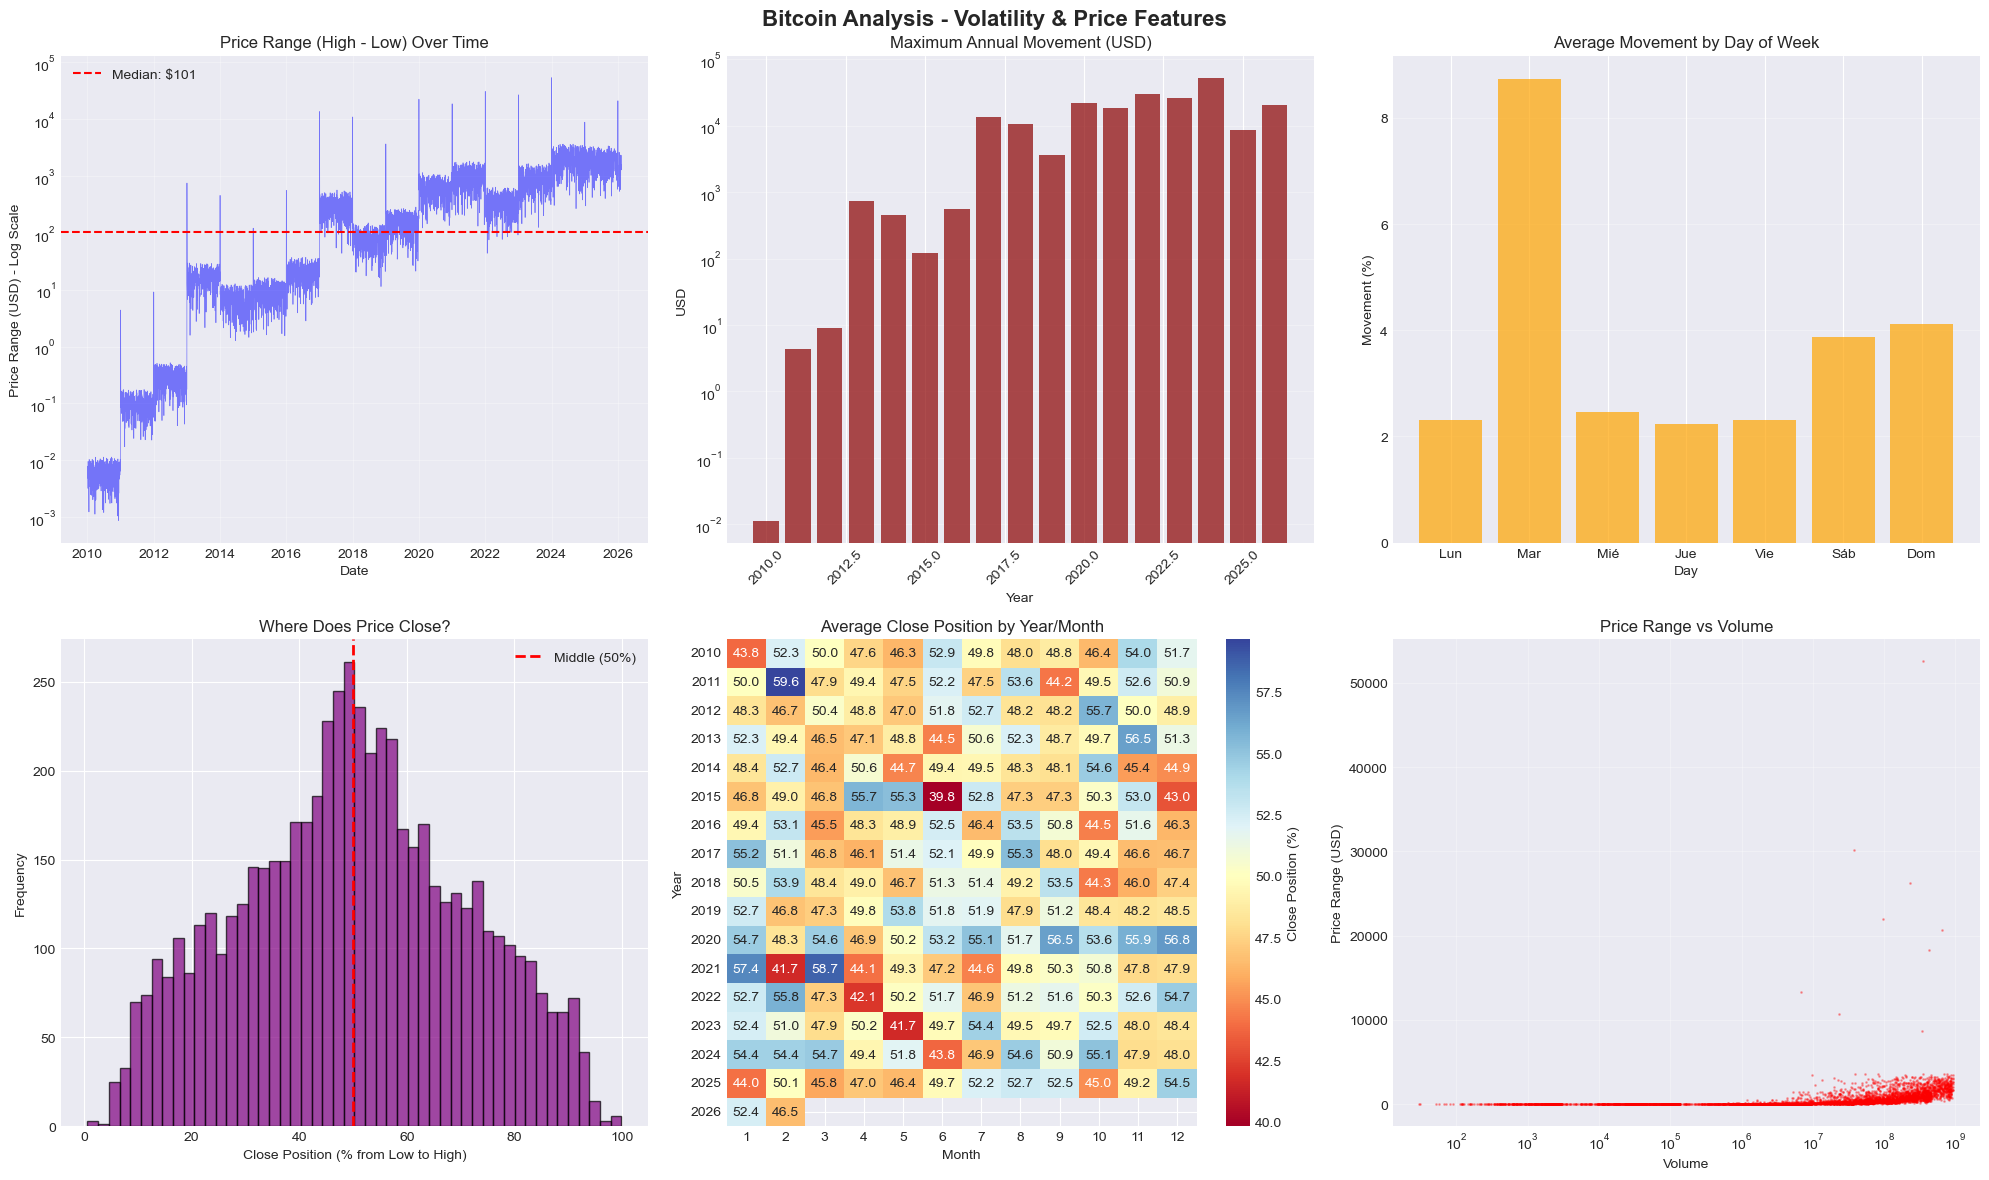

In [47]:
# Create a figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Bitcoin Analysis - Volatility & Price Features', fontsize=16, fontweight='bold')

# ─────────────────────────────────────────────────────────────
#  1: Price Range over time (posición [0,0])
# ─────────────────────────────────────────────────────────────
axes[0, 0].set_yscale('log')
axes[0, 0].plot(bitcoin_analyzed['Date'], bitcoin_analyzed['PriceRange'], 
                alpha=0.5, linewidth=0.5, color='blue')
axes[0, 0].axhline(y=bitcoin_analyzed['PriceRange'].median(), color='red', linestyle='--', 
                   label=f'Median: ${bitcoin_analyzed["PriceRange"].median():.0f}')
axes[0, 0].set_title('Price Range (High - Low) Over Time', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price Range (USD) - Log Scale')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# ─────────────────────────────────────────────────────────────
#  2: Maximum Annual Movement (posición [0,1])
# ─────────────────────────────────────────────────────────────
max_by_year = bitcoin_analyzed.groupby('Year')['PriceRange'].max()
axes[0, 1].bar(max_by_year.index, max_by_year.values, color='darkred', alpha=0.7)
axes[0, 1].set_title('Maximum Annual Movement (USD)', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('USD')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
#  3: Movement by Day of Week (posición [0,2])
# ─────────────────────────────────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

mov_by_day = [bitcoin_analyzed[bitcoin_analyzed['DayOfWeek'] == day]['PriceRange_Pct'].mean() 
              for day in day_order]
axes[0, 2].bar(day_names_es, mov_by_day, color='orange', alpha=0.7)
axes[0, 2].set_title('Average Movement by Day of Week', fontsize=12)
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_ylabel('Movement (%)')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
#  4: Close Position Distribution (posición [1,0])
# ─────────────────────────────────────────────────────────────
axes[1, 0].hist(bitcoin_analyzed['Close_Position'].dropna(), bins=50, 
                edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Middle (50%)')
axes[1, 0].set_title('Where Does Price Close?', fontsize=12)
axes[1, 0].set_xlabel('Close Position (% from Low to High)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# ─────────────────────────────────────────────────────────────
#  5: Close Position Heatmap by Year/Month (posición [1,1])
# ─────────────────────────────────────────────────────────────
pivot_close = bitcoin_analyzed.pivot_table(
    values='Close_Position', 
    index='Year', 
    columns='Month',
    aggfunc='mean'
)
sns.heatmap(pivot_close, annot=True, fmt='.1f', cmap='RdYlBu', center=50, 
            ax=axes[1, 1], cbar_kws={'label': 'Close Position (%)'})
axes[1, 1].set_title('Average Close Position by Year/Month', fontsize=12)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Year')

# ─────────────────────────────────────────────────────────────
#  6: Price Range vs Volume (posición [1,2])
# ─────────────────────────────────────────────────────────────
axes[1, 2].scatter(bitcoin_analyzed['Volume'], bitcoin_analyzed['PriceRange'], 
                   alpha=0.3, s=1, color='red')
axes[1, 2].set_xlabel('Volume')
axes[1, 2].set_ylabel('Price Range (USD)')
axes[1, 2].set_title('Price Range vs Volume')
axes[1, 2].set_xscale('log')  # Log scale for volume
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

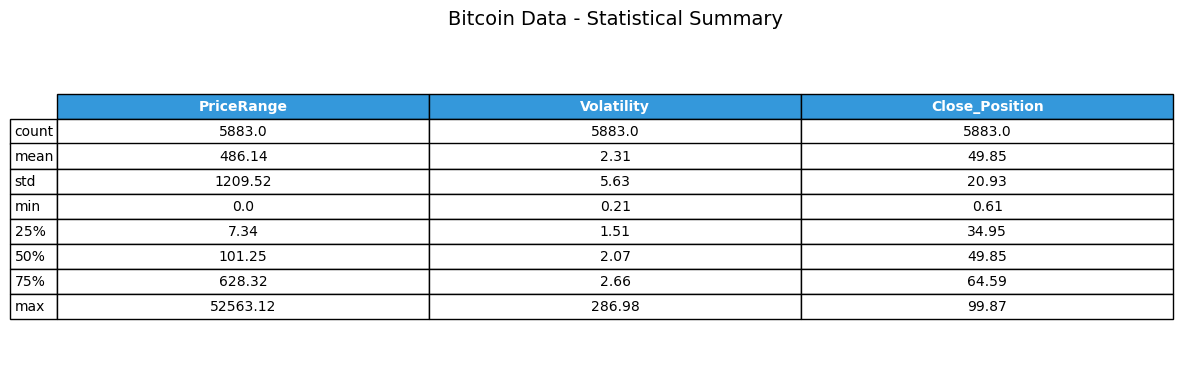

In [27]:
# Create a statistical summary table visualization
fig3, ax3 = plt.subplots(figsize=(12, 4))

# Calculate statistics
stats = bitcoin_analyzed[['PriceRange', 'Volatility', 'Close_Position']].describe().round(2)

# Hide axes
ax3.axis('tight')
ax3.axis('off')

# Create table
table = ax3.table(cellText=stats.values,
                  rowLabels=stats.index,
                  colLabels=stats.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#3498db']*3)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color the header
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#3498db')
        cell.set_text_props(color='white', weight='bold')

ax3.set_title('Bitcoin Data - Statistical Summary', fontsize=14, pad=20)
plt.show()

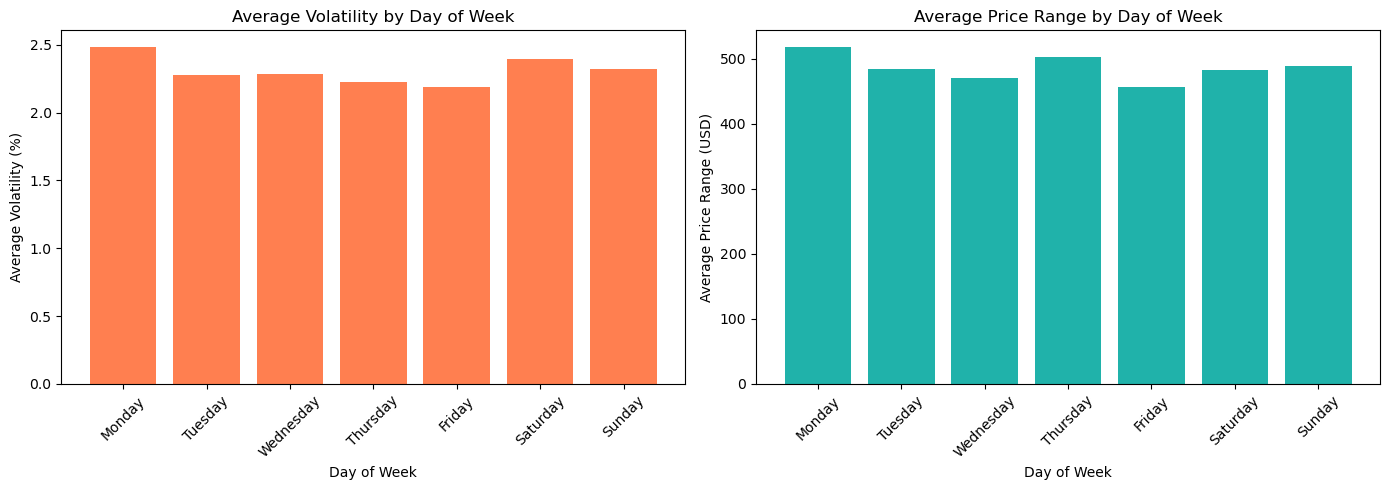

In [28]:
# Analyze volatility by day of week
bitcoin_analyzed['DayOfWeek'] = pd.to_datetime(bitcoin_analyzed['Date']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig4, (ax4_1, ax4_2) = plt.subplots(1, 2, figsize=(14, 5))

# Average volatility by day
vol_by_day = bitcoin_analyzed.groupby('DayOfWeek')['Volatility'].mean().reindex(day_order)
ax4_1.bar(vol_by_day.index, vol_by_day.values, color='coral')
ax4_1.set_title('Average Volatility by Day of Week')
ax4_1.set_xlabel('Day of Week')
ax4_1.set_ylabel('Average Volatility (%)')
ax4_1.tick_params(axis='x', rotation=45)

# Average PriceRange by day
range_by_day = bitcoin_analyzed.groupby('DayOfWeek')['PriceRange'].mean().reindex(day_order)
ax4_2.bar(range_by_day.index, range_by_day.values, color='lightseagreen')
ax4_2.set_title('Average Price Range by Day of Week')
ax4_2.set_xlabel('Day of Week')
ax4_2.set_ylabel('Average Price Range (USD)')
ax4_2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

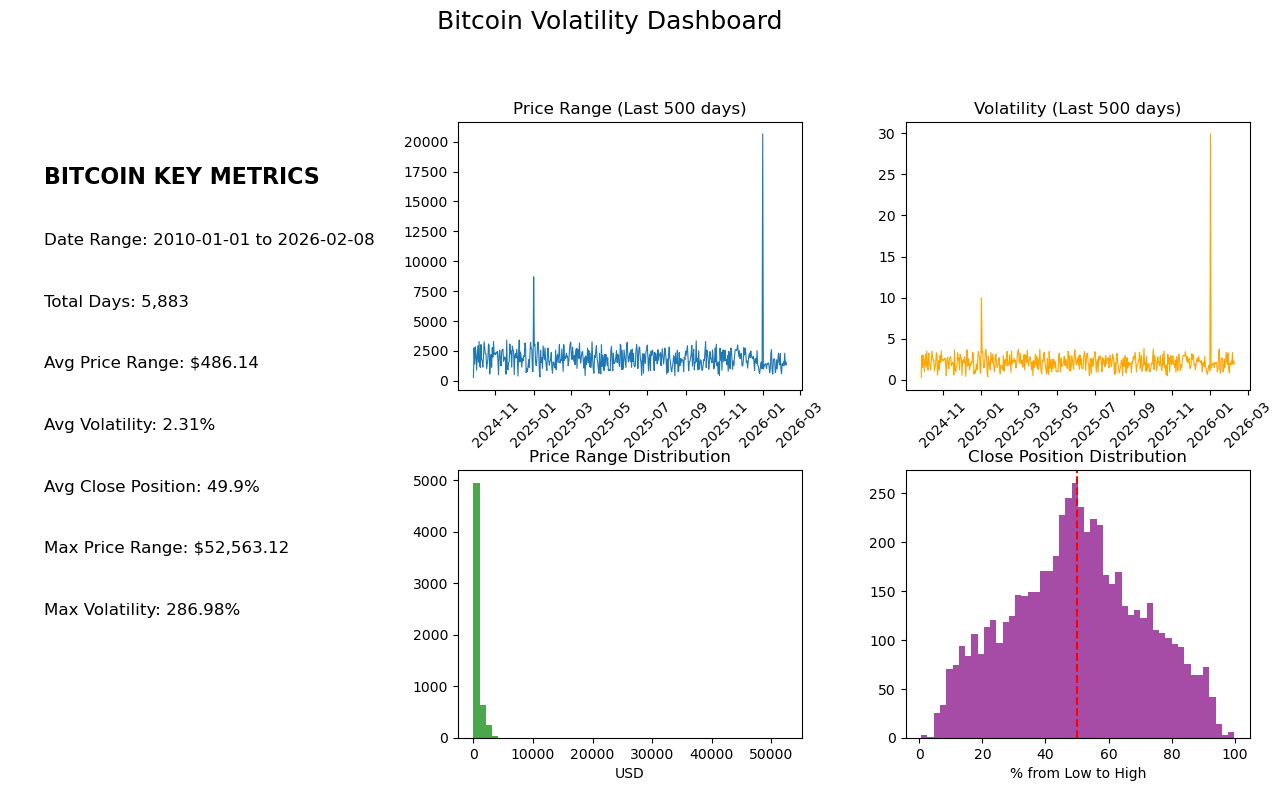

In [29]:
# Create a dashboard of key metrics
fig5 = plt.figure(figsize=(16, 8))
gs = fig5.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Overall stats as text
ax_main = fig5.add_subplot(gs[:, 0])
ax_main.axis('off')
ax_main.text(0.1, 0.9, 'BITCOIN KEY METRICS', fontsize=16, weight='bold')
ax_main.text(0.1, 0.8, f"Date Range: {bitcoin_analyzed['Date'].min().strftime('%Y-%m-%d')} to {bitcoin_analyzed['Date'].max().strftime('%Y-%m-%d')}", fontsize=12)
ax_main.text(0.1, 0.7, f"Total Days: {len(bitcoin_analyzed):,}", fontsize=12)
ax_main.text(0.1, 0.6, f"Avg Price Range: ${bitcoin_analyzed['PriceRange'].mean():,.2f}", fontsize=12)
ax_main.text(0.1, 0.5, f"Avg Volatility: {bitcoin_analyzed['Volatility'].mean():.2f}%", fontsize=12)
ax_main.text(0.1, 0.4, f"Avg Close Position: {bitcoin_analyzed['Close_Position'].mean():.1f}%", fontsize=12)
ax_main.text(0.1, 0.3, f"Max Price Range: ${bitcoin_analyzed['PriceRange'].max():,.2f}", fontsize=12)
ax_main.text(0.1, 0.2, f"Max Volatility: {bitcoin_analyzed['Volatility'].max():.2f}%", fontsize=12)

# Price Range trend
ax1 = fig5.add_subplot(gs[0, 1])
ax1.plot(bitcoin_analyzed['Date'].tail(500), bitcoin_analyzed['PriceRange'].tail(500), linewidth=0.8)
ax1.set_title('Price Range (Last 500 days)')
ax1.tick_params(axis='x', rotation=45)

# Volatility trend
ax2 = fig5.add_subplot(gs[0, 2])
ax2.plot(bitcoin_analyzed['Date'].tail(500), bitcoin_analyzed['Volatility'].tail(500), linewidth=0.8, color='orange')
ax2.set_title('Volatility (Last 500 days)')
ax2.tick_params(axis='x', rotation=45)

# PriceRange histogram
ax3 = fig5.add_subplot(gs[1, 1])
ax3.hist(bitcoin_analyzed['PriceRange'].dropna(), bins=50, color='green', alpha=0.7)
ax3.set_title('Price Range Distribution')
ax3.set_xlabel('USD')

# Close Position histogram
ax4 = fig5.add_subplot(gs[1, 2])
ax4.hist(bitcoin_analyzed['Close_Position'].dropna(), bins=50, color='purple', alpha=0.7)
ax4.set_title('Close Position Distribution')
ax4.set_xlabel('% from Low to High')
ax4.axvline(x=50, color='red', linestyle='--')

plt.suptitle('Bitcoin Volatility Dashboard', fontsize=18, y=1.02)
plt.show()

## PriceCategory Analysis

🔍 PRICECATEGORY ANALYSIS

📊 DAY DISTRIBUTION BY CATEGORY:
PriceCategory
High      1866
Low       2191
Medium    1826
Name: count, dtype: int64

Percentages:
PriceCategory
High      31.7%
Low       37.2%
Medium    31.0%
Name: count, dtype: object

📈 PRICE STATISTICS BY CATEGORY

🔹 CATEGORY: Low
----------------------------------------
          Open     High      Low    Close
count  2191.00  2191.00  2191.00  2191.00
mean    253.56   256.69   250.72   253.76
std     279.94   283.16   276.79   279.91
min       0.30     0.30     0.29     0.30
25%       4.61     4.65     4.56     4.61
50%      13.53    13.80    13.52    13.53
75%     430.57   435.08   426.13   430.57
max     754.01   769.06   753.23   754.01

📅 Date range: 2010-01-01 to 2015-12-31
📊 Avg volatility (High-Low): $5.97
📊 Avg volatility (%): 2.28%

🔹 CATEGORY: Medium
----------------------------------------
           Open      High       Low     Close
count   1826.00   1826.00   1826.00   1826.00
mean    8529.24   8626.95   84

C:\Users\aleja\AppData\Local\Temp\ipykernel_46692\2608423220.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(price_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
C:\Users\aleja\AppData\Local\Temp\ipykernel_46692\2608423220.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(vol_data, labels=['Low', 'Medium', 'High'], patch_artist=True)


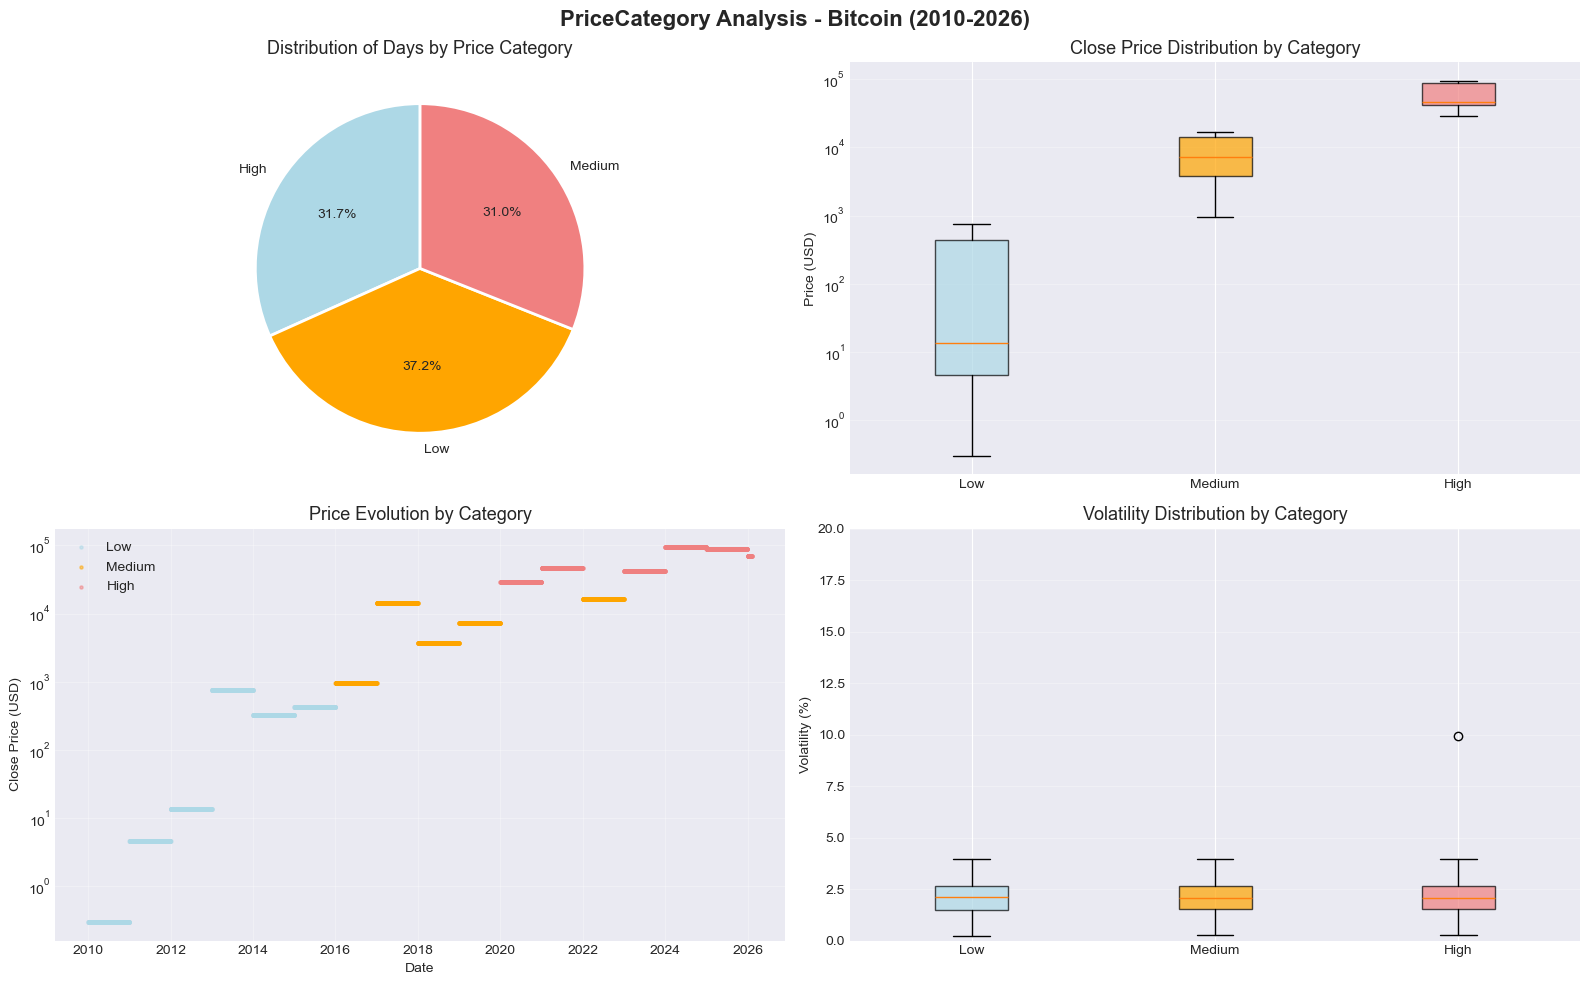

In [53]:

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# ─────────────────────────────────────────────────────────────
# 1. CATEGORY DISTRIBUTION (how many days in each?)
# ─────────────────────────────────────────────────────────────
print("🔍 PRICECATEGORY ANALYSIS")
print("=" * 60)

# Count days by category
category_counts = bitcoin_analyzed['PriceCategory'].value_counts().sort_index()
print("\n📊 DAY DISTRIBUTION BY CATEGORY:")
print(category_counts)
print(f"\nPercentages:")
print((category_counts / len(bitcoin_analyzed) * 100).round(1).astype(str) + '%')

# ─────────────────────────────────────────────────────────────
# 2. DESCRIPTIVE STATISTICS BY CATEGORY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📈 PRICE STATISTICS BY CATEGORY")
print("=" * 60)

# Select price columns to analyze
price_columns = ['Open', 'High', 'Low', 'Close']

for category in ['Low', 'Medium', 'High']:
    print(f"\n🔹 CATEGORY: {category}")
    print("-" * 40)
    
    # Filter data for this category
    category_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    
    # Descriptive statistics
    stats = category_data[price_columns].describe()
    print(stats.round(2))
    
    # Additional information
    print(f"\n📅 Date range: {category_data['Date'].min().strftime('%Y-%m-%d')} to {category_data['Date'].max().strftime('%Y-%m-%d')}")
    print(f"📊 Avg volatility (High-Low): ${category_data['PriceRange'].mean():.2f}")
    print(f"📊 Avg volatility (%): {category_data['Volatility'].mean():.2f}%")

# ─────────────────────────────────────────────────────────────
# 3. VISUALIZATIONS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PriceCategory Analysis - Bitcoin (2010-2026)', fontsize=16, fontweight='bold')

# Chart 1: Category distribution (pie chart)
colors = ['lightblue', 'orange', 'lightcoral']
axes[0, 0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title('Distribution of Days by Price Category', fontsize=13)

# Chart 2: Boxplot of prices by category
price_data = [bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == cat]['Close'] 
              for cat in ['Low', 'Medium', 'High']]
bp = axes[0, 1].boxplot(price_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[0, 1].set_title('Close Price Distribution by Category', fontsize=13)
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Chart 3: Temporal evolution by category
colors_map = {'Low': 'lightblue', 'Medium': 'orange', 'High': 'lightcoral'}
for category in ['Low', 'Medium', 'High']:
    cat_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    axes[1, 0].scatter(cat_data['Date'], cat_data['Close'], 
                       label=category, color=colors_map[category], 
                       alpha=0.5, s=5)
axes[1, 0].set_title('Price Evolution by Category', fontsize=13)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Close Price (USD)')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Volatility by category
vol_data = [bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == cat]['Volatility'] 
            for cat in ['Low', 'Medium', 'High']]
bp2 = axes[1, 1].boxplot(vol_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
for box, color in zip(bp2['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[1, 1].set_title('Volatility Distribution by Category', fontsize=13)
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].set_ylim(0, 20)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [49]:
print("\n" + "=" * 60)
print("📊 PRICECATEGORY SUMMARY TABLE")
print("=" * 60)

summary_data = []
for category in ['Low', 'Medium', 'High']:
    cat_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    
    summary_data.append({
        'Category': category,
        'Days': len(cat_data),
        'Percentage': f"{len(cat_data)/len(bitcoin_analyzed)*100:.1f}%",
        'Price Range': f"${cat_data['Close'].min():.0f} - ${cat_data['Close'].max():.0f}",
        'Mean Close': f"${cat_data['Close'].mean():.0f}",
        'Median Close': f"${cat_data['Close'].median():.0f}",
        'Mean Volatility': f"{cat_data['Volatility'].mean():.1f}%",
        'Period': f"{cat_data['Date'].min().strftime('%Y')}-{cat_data['Date'].max().strftime('%Y')}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


📊 PRICECATEGORY SUMMARY TABLE
Category  Days Percentage     Price Range Mean Close Median Close Mean Volatility    Period
     Low  2191      37.2%       $0 - $754       $254          $14            2.3% 2010-2015
  Medium  1826      31.0%   $964 - $16548      $8517        $7194            2.4% 2016-2022
    High  1866      31.7% $29002 - $93429     $59898       $46306            2.2% 2020-2026


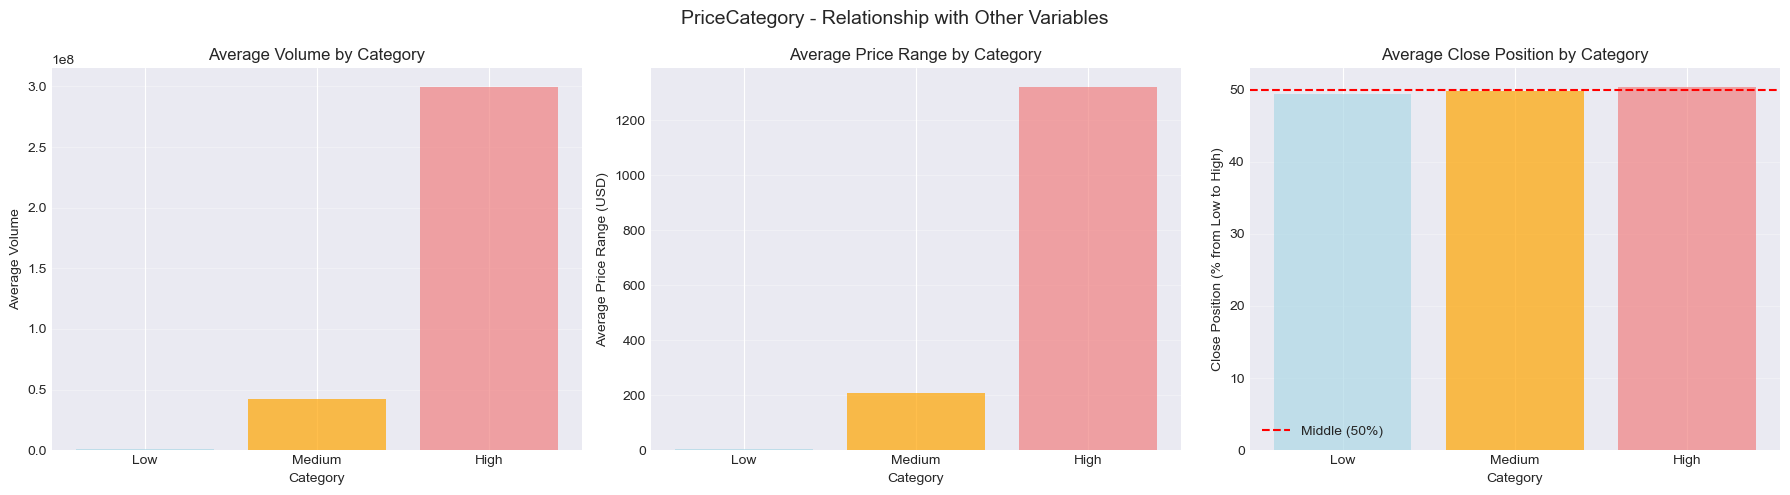

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PriceCategory - Relationship with Other Variables', fontsize=14)

# 1. Volume by category
for i, category in enumerate(['Low', 'Medium', 'High']):
    vol_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['Volume'].mean()
    axes[0].bar(i, vol_mean, color=colors[i], alpha=0.7, label=category)
axes[0].set_title('Average Volume by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Volume')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].grid(True, alpha=0.3, axis='y')

# 2. PriceRange by category
for i, category in enumerate(['Low', 'Medium', 'High']):
    range_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['PriceRange'].mean()
    axes[1].bar(i, range_mean, color=colors[i], alpha=0.7)
axes[1].set_title('Average Price Range by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Price Range (USD)')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Close Position by category
for i, category in enumerate(['Low', 'Medium', 'High']):
    pos_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['Close_Position'].mean()
    axes[2].bar(i, pos_mean, color=colors[i], alpha=0.7)
axes[2].axhline(y=50, color='red', linestyle='--', label='Middle (50%)')
axes[2].set_title('Average Close Position by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Close Position (% from Low to High)')
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['Low', 'Medium', 'High'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [51]:
print("\n" + "=" * 60)
print("🔍 PRICECATEGORY INTERPRETATION")
print("=" * 60)

print("""
📌 WHAT DOES EACH CATEGORY MEAN?

• LOW: Low price days (early Bitcoin years, 2010-2013)
   - Very low prices (cents or few dollars)
   - Low USD volatility, high % volatility
   - Low trading volume

• MEDIUM: Growth period (approx. 2014-2020)
   - Intermediate prices ($100 - $10,000)
   - Moderate volatility
   - Developing market

• HIGH: Recent era (2021-2026)
   - High prices (> $10,000)
   - High USD volatility, lower % volatility
   - High volume, mature market

📊 DISTRIBUTION SHOULD BE APPROXIMATELY EQUAL
   (33% each) BECAUSE IT WAS CREATED USING QUANTILES.
""")

# Check if distribution is uniform
expected = len(bitcoin_analyzed) / 3
print(f"\n✅ Ideal distribution (33.3% each): {expected:.0f} days per category")
print("📊 Actual distribution:")
for cat, count in category_counts.items():
    diff = ((count - expected) / expected * 100)
    print(f"   {cat}: {count} days ({diff:+.1f}% vs ideal)")


🔍 PRICECATEGORY INTERPRETATION

📌 WHAT DOES EACH CATEGORY MEAN?

• LOW: Low price days (early Bitcoin years, 2010-2013)
   - Very low prices (cents or few dollars)
   - Low USD volatility, high % volatility
   - Low trading volume

• MEDIUM: Growth period (approx. 2014-2020)
   - Intermediate prices ($100 - $10,000)
   - Moderate volatility
   - Developing market

• HIGH: Recent era (2021-2026)
   - High prices (> $10,000)
   - High USD volatility, lower % volatility
   - High volume, mature market

📊 DISTRIBUTION SHOULD BE APPROXIMATELY EQUAL
   (33% each) BECAUSE IT WAS CREATED USING QUANTILES.


✅ Ideal distribution (33.3% each): 1961 days per category
📊 Actual distribution:
   High: 1866 days (-4.8% vs ideal)
   Low: 2191 days (+11.7% vs ideal)
   Medium: 1826 days (-6.9% vs ideal)
